# Many Raters, One Mask?

### A practical guide to consensus aggregation for multi-annotator medical image segmentation

This notebook is the runnable companion to the tutorial blog post. It applies six consensus methods to two multi-annotator datasets and produces all the visualizations.

**Methods**: Majority Voting and Mask Averaging, STAPLE (Warfield et al., 2004), SIMPLE (Langerak et al., 2010), MACCHIatO-D (Hamzaoui et al., 2023), and Soft-STAPLE (Kats et al., 2019).

**Datasets**: QUBIQ 2021 brain-growth (7 raters, T1 MRI) and IMA++ (multi-annotator dermoscopy). The data is not available in this GitHub repository. Download your own and set `CONSENSUS_DATA_ROOT` to your dataset path. Everything runs on CPU in a couple of minutes.

## Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.patches import Circle
from scipy import ndimage as ndi
from skimage.morphology import binary_dilation, disk

sys.path.insert(0, str(Path("..").resolve()))

from src.config import IMA_CASE, QUBIQ_CASE
from src.data_loading import load_case
from src.metrics import (avg_pairwise_dice, dice, majority_vote, mask_average,
                         vote_map)
from src.soft_staple import generate_soft_labels, soft_staple
from src.viz import (OKABE_ITO, SOFT_CMAP, VOTE_CMAP, HARD_COLOR, ATTENTION_COLOR,
                     CONTOUR_LW, RATER_LW, FILL_ALPHA, PLOT_INK, fill_hex,
                     crop_case, apply_crop, soft_alpha_ramp, gray_bg_alpha,
                     soft_over_image_rgba, raters_overlay_rgba, panel_title, save_fig)

DATA_ROOT = Path(os.environ.get("CONSENSUS_DATA_ROOT", "../../data")).resolve()
FIG_DIR = Path(os.environ.get("CONSENSUS_FIG_DIR", "../../figures")).resolve()
PRECOMP_DIR = Path(os.environ.get("CONSENSUS_PRECOMP_DIR", "../../precomputed")).resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)
PRECOMP_DIR.mkdir(parents=True, exist_ok=True)

# Figures are saved transparent (no fixed facecolor) and themed at save time.
plt.rcParams.update({"savefig.dpi": 150, "figure.dpi": 110})
print("data root:", DATA_ROOT, "| figures ->", FIG_DIR)

data root: /home/ka/GitHub/Research/MEC-consensus-submission/data | figures -> /home/ka/GitHub/Research/MEC-consensus-submission/figures


In [2]:
import SimpleITK as sitk
import macchiato, nibabel, LabelFusion
print("numpy", np.__version__, "| SimpleITK", sitk.Version.VersionString(),
      "| nibabel", nibabel.__version__, "| LabelFusion", LabelFusion.__version__)

numpy 1.23.5 | SimpleITK 2.4.1 | nibabel 5.2.1 | LabelFusion 1.0.15


### Plotting helpers

Soft consensus maps use `viridis_r` overlaid atop the image with an alpha (high consensus = dark); individual raters are translucent fills plus a solid same-colour 2px contour; hard consensus is a white contour. Titles are white glyphs with a dark halo placed on the panel, so each figure is a single PNG legible on a light or a dark page. QUBIQ panels are cropped to the brain.

In [3]:
def show_soft(ax, image, soft, is_rgb=False, title=""):
    ax.imshow(soft_over_image_rgba(image, soft, is_rgb=is_rgb))
    if title:
        panel_title(ax, title)
    ax.axis("off")

def show_image(ax, image, is_rgb=False):
    if is_rgb:
        ax.imshow(image)
    else:                                     # greyscale: background padding -> transparent
        g = np.clip(image, 0, 1)
        ax.imshow(np.dstack([g, g, g, gray_bg_alpha(image)]))

def show_raters(ax, image, masks, is_rgb=False, title=""):
    ax.imshow(raters_overlay_rgba(image, masks, is_rgb=is_rgb,
                                  alpha=FILL_ALPHA, lw=1))     # fills + solid contours
    if title:
        panel_title(ax, title)
    ax.axis("off")

def show_hard(ax, image, hard, is_rgb=False, title="", lw=CONTOUR_LW):
    show_image(ax, image, is_rgb)
    if np.asarray(hard).any():
        ax.contour(hard, levels=[0.5], colors=[HARD_COLOR], linewidths=lw)
    if title:
        panel_title(ax, title)
    ax.axis("off")

def soft_colorbar(fig, cax):
    # Draw the colorbar in its own axes.
    sm = cm.ScalarMappable(norm=Normalize(0, 1), cmap=SOFT_CMAP)
    cb = fig.colorbar(sm, cax=cax)
    cb.ax.tick_params(colors=PLOT_INK)              # neutral -> reads on light or dark
    cb.outline.set_edgecolor(PLOT_INK)
    return cb

## The consensus methods

STAPLE, SIMPLE and MACCHIatO wrap existing implementations; soft-STAPLE and the
simple operators come from the `src/` library.

In [4]:
def run_staple(masks_np):
    imgs = [sitk.Cast(sitk.GetImageFromArray(masks_np[k]), sitk.sitkUInt8)
            for k in range(len(masks_np))]
    f = sitk.STAPLEImageFilter(); f.SetForegroundValue(1)
    soft = sitk.GetArrayFromImage(f.Execute(imgs))
    # SimpleITK 2.4.1: these take NO index and return all K values at once.
    return soft.astype(np.float32), np.array(f.GetSensitivity()), np.array(f.GetSpecificity())

def run_simple(masks_np, class_list=(0, 1)):
    from LabelFusion.wrapper import fuse_images
    imgs = [sitk.Cast(sitk.GetImageFromArray(masks_np[k]), sitk.sitkUInt8)
            for k in range(len(masks_np))]
    return sitk.GetArrayFromImage(fuse_images(imgs, "simple", class_list=list(class_list))).astype(np.uint8)

def run_macchiato(masks_np):
    from macchiato.hard_consensus import Hard_MACCHIatO
    from macchiato.soft_consensus import Soft_MACCHIatO
    from macchiato.utils import soft_dice
    ml = [masks_np[k].astype(float) for k in range(masks_np.shape[0])]
    hard = np.asarray(Hard_MACCHIatO(ml, dist=soft_dice, verbose=False)).astype(np.uint8)
    soft = np.asarray(Soft_MACCHIatO(ml, dist=soft_dice, verbose=False)).astype(np.float32)
    return hard, soft

## The two worked examples

**Dataset 1: QUBIQ brain-growth (7 raters, T1 MRI).** We use `case21`, and crop the display to the brain (which otherwise occupies barely a tenth of its 256x256 frame).

**Dataset 2: IMA++ dermoscopy (5 raters, RGB).** We use `ISIC_0010183`. 

Both are loaded in the cell below and both are carried through every method that follows.

In [5]:
qdir = DATA_ROOT / QUBIQ_CASE["rel_dir"]
qubiq = load_case(str(qdir), QUBIQ_CASE["image_name"], str(qdir), QUBIQ_CASE["seg_names"], modality="nifti")
qubiq_masks = qubiq["masks"]
q_img_c, q_masks_c, q_crop = crop_case(qubiq["image"], qubiq_masks, "nifti")
qc = lambda arr: apply_crop(arr, *q_crop)
print("QUBIQ", QUBIQ_CASE["name"], "brain crop", q_img_c.shape,
      "| avg pairwise Dice =", round(avg_pairwise_dice(qubiq_masks), 3))

ima = load_case(str(DATA_ROOT / IMA_CASE["images_rel_dir"]), IMA_CASE["image_name"],
                str(DATA_ROOT / IMA_CASE["segs_rel_dir"]), IMA_CASE["seg_names"], modality="image")
ima_masks = ima["masks"]
print("IMA++", IMA_CASE["name"], ima_masks.shape, "| avg pairwise Dice =", round(avg_pairwise_dice(ima_masks), 3))

QUBIQ case21 brain crop (101, 123) | avg pairwise Dice = 0.781
IMA++ ISIC_0010183 (5, 768, 1024) | avg pairwise Dice = 0.776


## Majority Voting (MV) and Mask Averaging (MA)

Majority voting thresholds the vote map at $K/2$ (ties to foreground). Mask averaging retains the fractional agreement. Because MV decides each pixel independently, it can
leave an isolated speck where a bare majority overlaps.

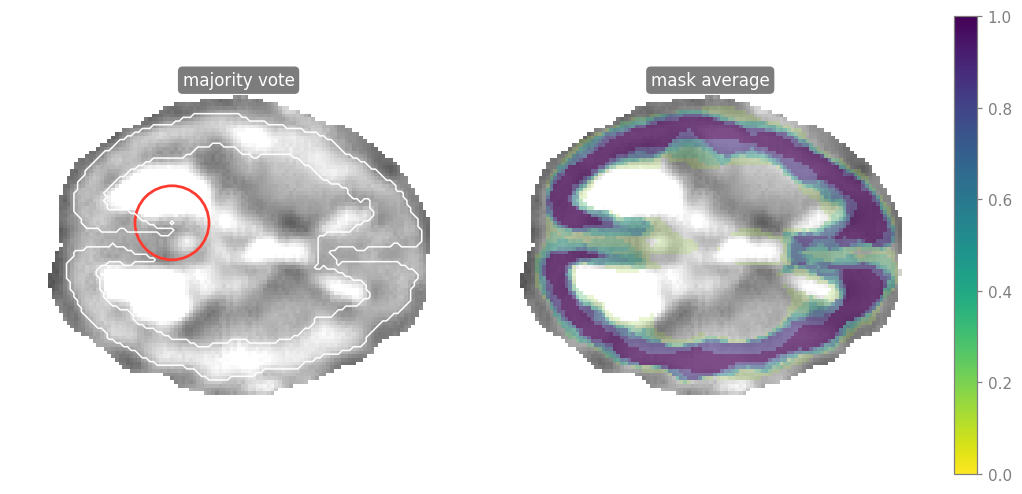

QUBIQ MV 2246 | IMA++ MV 44795


In [6]:
qubiq_mv, qubiq_ma = majority_vote(qubiq_masks), mask_average(qubiq_masks)
ima_mv, ima_ma = majority_vote(ima_masks), mask_average(ima_masks)

mv_c = qc(qubiq_mv)
lbl, n = ndi.label(mv_c)
sizes = ndi.sum(np.ones_like(lbl), lbl, index=range(1, n + 1)) if n else np.array([])
main = sizes.max() if n else 0
fig, axd = plt.subplot_mosaic([["mv", "ma", "cb"]], figsize=(9.4, 4.6),
                              gridspec_kw={"width_ratios": [1, 1, 0.05]})
show_hard(axd["mv"], q_img_c, mv_c, title="majority vote")
for cid, s in enumerate(sizes, 1):
    if s < 0.05 * main:
        ys, xs = np.where(lbl == cid)
        axd["mv"].add_patch(Circle((xs.mean(), ys.mean()), 10, fill=False, edgecolor=ATTENTION_COLOR, linewidth=1.8))
show_soft(axd["ma"], q_img_c, qc(qubiq_ma), title="mask average"); soft_colorbar(fig, axd["cb"])
fig.tight_layout(); save_fig(fig, str(FIG_DIR / "mv_isolated_voxels")); plt.show()
print("QUBIQ MV", int(qubiq_mv.sum()), "| IMA++ MV", int(ima_mv.sum()))

## STAPLE

STAPLE estimates each rater's sensitivity and specificity by expectation-maximisation (EM) and weights raters by reliability. Because specificity is estimated
over the background, the field of view affects the consensus.

QUBIQ sensitivity: [0.695 0.734 0.784 0.709 0.818 0.745 0.82 ]
QUBIQ specificity: [0.999 0.998 1.    0.999 0.998 0.999 0.995]


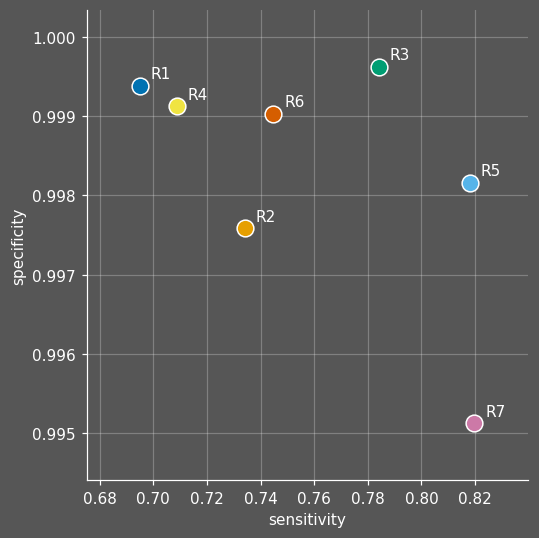

In [7]:
qubiq_staple, q_sens, q_spec = run_staple(qubiq_masks)
ima_staple, i_sens, i_spec = run_staple(ima_masks)
print("QUBIQ sensitivity:", np.round(q_sens, 3))
print("QUBIQ specificity:", np.round(q_spec, 3))

# background-size demo: full frame vs a tight crop, each shown at its own scale.
def tight_bbox(u, pad=5):
    ys, xs = np.where(u > 0); H, W = u.shape
    return (max(0, ys.min()-pad), min(H, ys.max()+1+pad), max(0, xs.min()-pad), min(W, xs.max()+1+pad))
union = np.clip(qubiq_masks.sum(0), 0, 1)
y0, y1, x0, x1 = tight_bbox(union)
staple_tight_crop, _, _ = run_staple(qubiq_masks[:, y0:y1, x0:x1])
staple_tight = np.zeros(qubiq_masks.shape[1:], np.float32); staple_tight[y0:y1, x0:x1] = staple_tight_crop
staple_tight_dims = np.array([y1-y0, x1-x0], np.int32)

# per-rater sensitivity/specificity scatter. This is the one panel with no image to
# sit on, so it gets a self-contained neutral background and white ink -> one version.
SCAT_BG = "#565656"
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_facecolor(SCAT_BG)
for k, (se, sp) in enumerate(zip(q_sens, q_spec)):
    ax.scatter(se, sp, color=fill_hex(k), s=120, zorder=3, edgecolor="white", linewidth=1.0)
    ax.annotate(f"R{k+1}", (se, sp), textcoords="offset points", xytext=(7, 5),
                color="white", fontsize=10)
ax.set_xlabel("sensitivity", color="white"); ax.set_ylabel("specificity", color="white")
ax.tick_params(colors="white")
ax.grid(alpha=0.25, color="white")
ax.margins(0.16)
for side in ("top", "right"):                       # despine so labels never touch a line
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("white")
fig.tight_layout(); save_fig(fig, str(FIG_DIR / "staple_raters"), bg=SCAT_BG); plt.show()

## SIMPLE

SIMPLE estimates a consensus, scores each rater against it, discards the raters below a threshold, and repeats.

Note: adding a single *blank* annotation does not affect STAPLE. The EM drives that rater's sensitivity to 0 and its specificity to 1, so its likelihood ratio is 1 at every voxel and it drops out of the consensus entirely, meaning STAPLE is self-correcting against an empty mask. However, correlated errors, e.g., several annotators making the same mistake, which violates the conditional-independence assumption the E-step rests on, does affect STAPLE. Below we add a systematically generous tracing (rater 1 dilated by a 12px disk) once, then three times, and watch how the methods are affected.

panel                        K     MV  STAPLE  SIMPLE
clean (7 raters)             7   2246    2939    2246
+1 generous                  8   2569    2939    2246
+3 generous (colluding)     10   2939    8241    2569
+1 blank                     8   2246    2939    2246


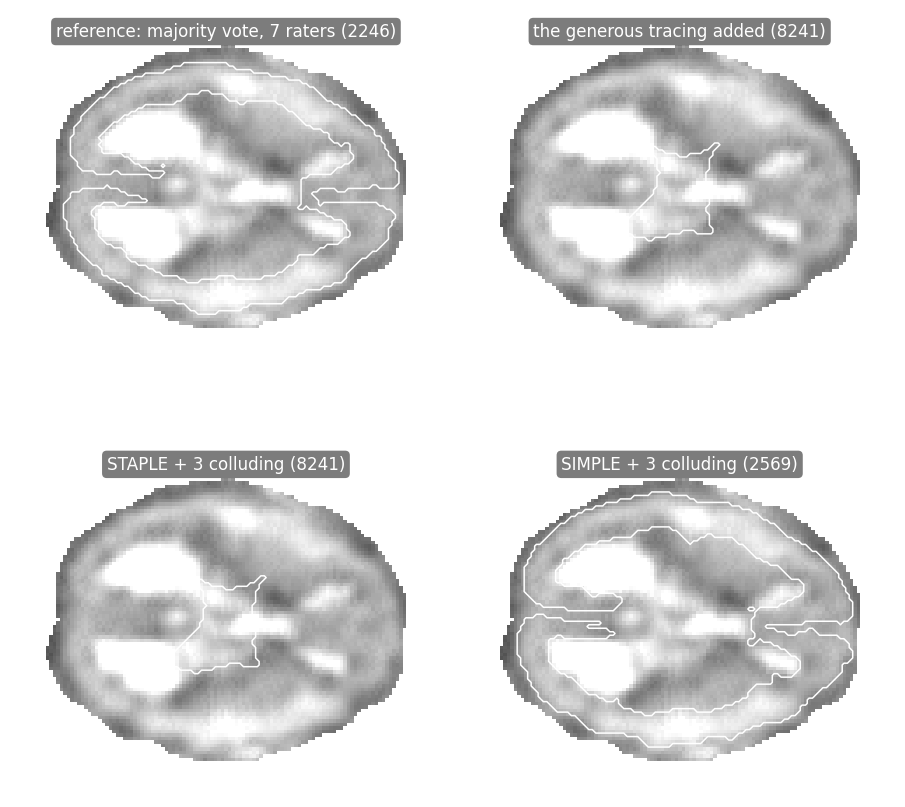

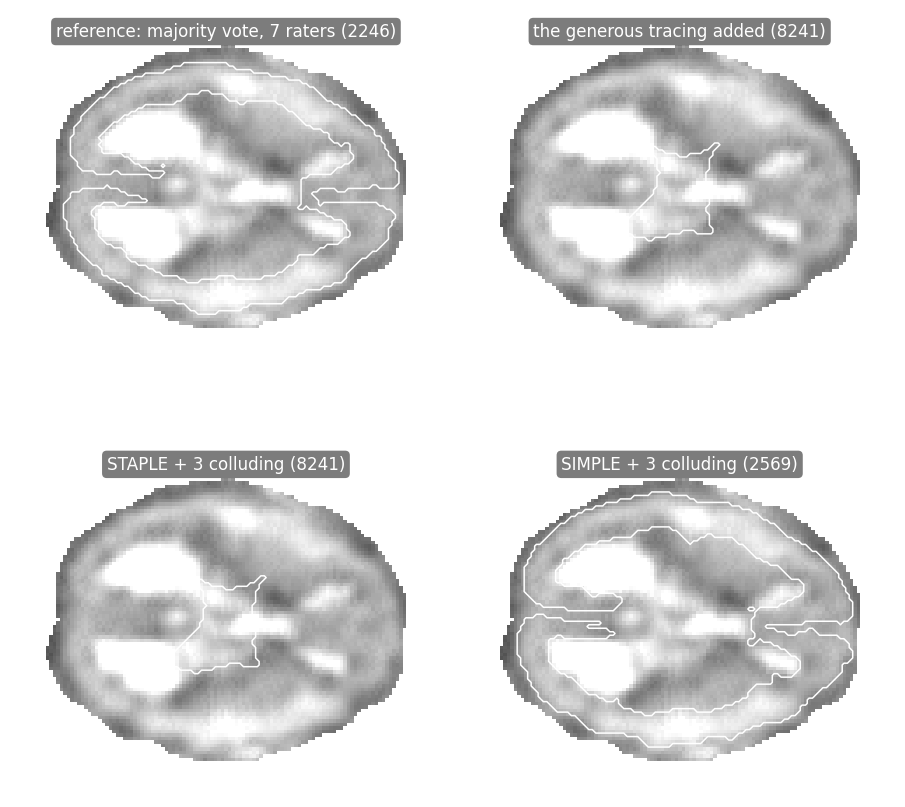

In [8]:
qubiq_simple = run_simple(qubiq_masks); ima_simple = run_simple(ima_masks)

# One "generous" annotator, i.e., over-segmentation. Adding copies of it simulates a correlated error, 
# meaning several annotators making the SAME mistake, which is what STAPLE cannot model.
generous = binary_dilation(qubiq_masks[0].astype(bool), disk(12)).astype(np.uint8)

def contaminate(n):
    return np.concatenate([qubiq_masks, np.repeat(generous[None], n, axis=0)], axis=0)

print(f"{'panel':26s} {'K':>3} {'MV':>6} {'STAPLE':>7} {'SIMPLE':>7}")
rows = {}
for label, mm in [("clean (7 raters)", qubiq_masks), ("+1 generous", contaminate(1)),
                  ("+3 generous (colluding)", contaminate(3)),
                  ("+1 blank", np.concatenate([qubiq_masks, np.zeros((1,) + qubiq_masks.shape[1:], np.uint8)]))]:
    s, _, _ = run_staple(mm); si = run_simple(mm)
    rows[label] = ((s > 0.5).astype(np.uint8), si)
    print(f"{label:26s} {len(mm):3d} {int((mm.sum(0) >= len(mm)/2).sum()):6d} "
          f"{int((s>0.5).sum()):7d} {int(si.sum()):7d}")

st3, si3 = rows["+3 generous (colluding)"]
fig, axd = plt.subplot_mosaic([["ref", "bad"], ["staple", "simple"]], figsize=(8.4, 8.6))
show_hard(axd["ref"], q_img_c, mv_c,
          title=f"reference: majority vote, 7 raters ({int(mv_c.sum())})")
show_hard(axd["bad"], q_img_c, qc(generous),
          title=f"the generous tracing added ({int(generous.sum())})")
show_hard(axd["staple"], q_img_c, qc(st3),
          title=f"STAPLE + 3 colluding ({int(st3.sum())})")
show_hard(axd["simple"], q_img_c, qc(si3),
          title=f"SIMPLE + 3 colluding ({int(si3.sum())})")
fig.tight_layout(); save_fig(fig, str(FIG_DIR / "simple_robustness")); plt.show()

# STAPLE is so severely affected that it adopts the generous segmentation entirely.
assert int(st3.sum()) == int(generous.sum()), "expected STAPLE to collapse onto the coalition"

## MACCHIatO-D

MACCHIatO is the Fréchet mean under Dice. MV and STAPLE on top, MACCHIatO-hard and soft at bottom.

QUBIQ: MV 2246  MACCHIatO 2443 (> MV)  union 3580
IMA++: MV 44795  MACCHIatO 42265 (< MV)  union 69120


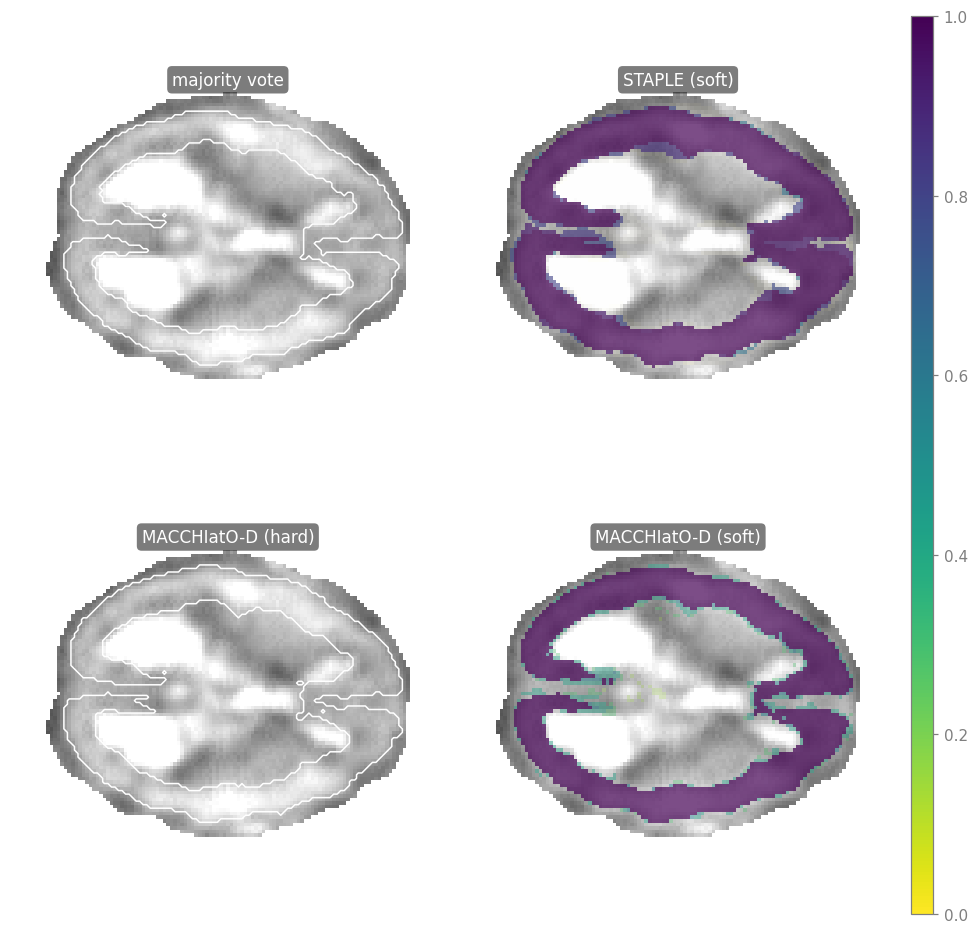

In [9]:
qubiq_mac_hard, qubiq_mac_soft = run_macchiato(qubiq_masks)
ima_mac_hard, ima_mac_soft = run_macchiato(ima_masks)
for tag, masks, mv, mac in [("QUBIQ", qubiq_masks, qubiq_mv, qubiq_mac_hard),
                            ("IMA++", ima_masks, ima_mv, ima_mac_hard)]:
    usz = int(np.clip(masks.sum(0), 0, 1).sum())
    assert mac.sum() <= usz, "MACCHIatO must not exceed the union"
    print(f"{tag}: MV {int(mv.sum())}  MACCHIatO {int(mac.sum())} ({'<' if mac.sum()<mv.sum() else '>'} MV)  union {usz}")

fig, axd = plt.subplot_mosaic([["mv", "staple", "cb"], ["mac_h", "mac_s", "cb"]],
                              figsize=(9.0, 8.6), gridspec_kw={"width_ratios": [1, 1, 0.05]})
show_hard(axd["mv"], q_img_c, qc(qubiq_mv), title="majority vote")
show_soft(axd["staple"], q_img_c, qc(qubiq_staple), title="STAPLE (soft)")
show_hard(axd["mac_h"], q_img_c, qc(qubiq_mac_hard), title="MACCHIatO-D (hard)")
show_soft(axd["mac_s"], q_img_c, qc(qubiq_mac_soft), title="MACCHIatO-D (soft)"); soft_colorbar(fig, axd["cb"])
fig.tight_layout(); save_fig(fig, str(FIG_DIR / "macchiato_comparison")); plt.show()

## Soft-STAPLE

Soft labels are built by dilating each mask and weighting the rim, so the rim radius
`r` and the rim weight `w` control how much boundary uncertainty the model ever sees.
That makes them an important parameter of the method. With a
narrow, faint rim, the result is visually indistinguishable from standard STAPLE.

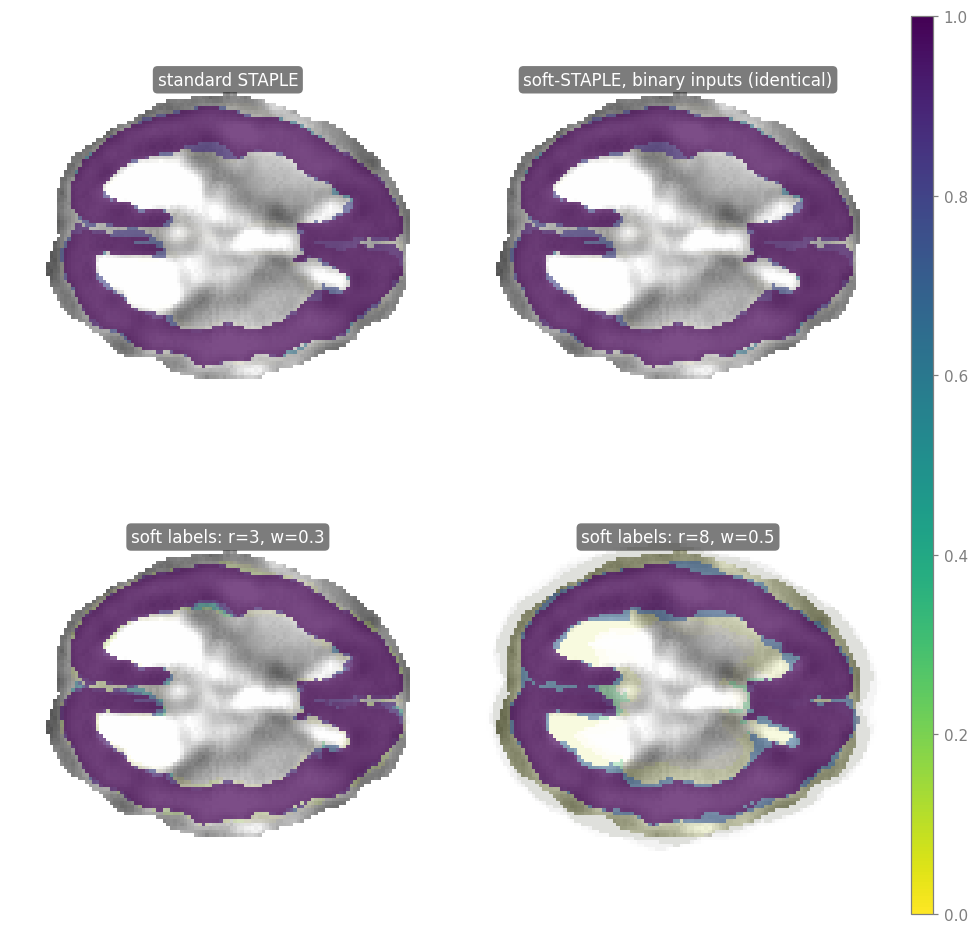

standard STAPLE    hard mask  2939 px | graded band  0.56% of frame
r=3, w=0.3         hard mask  2915 px | graded band  1.04% of frame
r=8, w=0.5         hard mask  3409 px | graded band  4.00% of frame


In [10]:
def soft_label_stack(masks, r=3, w=0.3):
    return np.stack([generate_soft_labels(masks[k], r, w) for k in range(len(masks))])
qubiq_soft_labels = soft_label_stack(qubiq_masks)
qubiq_ss_binary, _, _ = soft_staple(qubiq_masks.astype(float))
qubiq_ss_soft, ss_sens, ss_spec = soft_staple(qubiq_soft_labels)
qubiq_ss_wide, _, _ = soft_staple(soft_label_stack(qubiq_masks, r=8, w=0.5))
ima_ss_soft, _, _ = soft_staple(soft_label_stack(ima_masks))

# Feeding binary masks in must recover standard STAPLE exactly.
assert np.allclose(qubiq_ss_binary, qubiq_staple, atol=1e-6), "binary inputs must reproduce STAPLE"

fig, axd = plt.subplot_mosaic([["std", "bin", "cb"], ["soft", "wide", "cb"]],
                              figsize=(9.0, 8.6), gridspec_kw={"width_ratios": [1, 1, 0.05]})
show_soft(axd["std"], q_img_c, qc(qubiq_staple), title="standard STAPLE")
show_soft(axd["bin"], q_img_c, qc(qubiq_ss_binary), title="soft-STAPLE, binary inputs (identical)")
show_soft(axd["soft"], q_img_c, qc(qubiq_ss_soft), title="soft labels: r=3, w=0.3")
show_soft(axd["wide"], q_img_c, qc(qubiq_ss_wide), title="soft labels: r=8, w=0.5"); soft_colorbar(fig, axd["cb"])
fig.tight_layout(); save_fig(fig, str(FIG_DIR / "softstaple_comparison")); plt.show()

# "Graded" = pixels the consensus is genuinely unsure about, i.e., strictly interior
# to [0, 1].
def graded(a):
    return float(np.mean((a > 0.02) & (a < 0.98)))
for label, a in [("standard STAPLE", qubiq_staple), ("r=3, w=0.3", qubiq_ss_soft),
                 ("r=8, w=0.5", qubiq_ss_wide)]:
    print(f"{label:18s} hard mask {int((a>0.5).sum()):5d} px | graded band {100*graded(a):5.2f}% of frame")

## All methods side by side

Raw rater masks (translucent fills) in the first row, then each method, methods
down the rows and the two cases across the two columns.

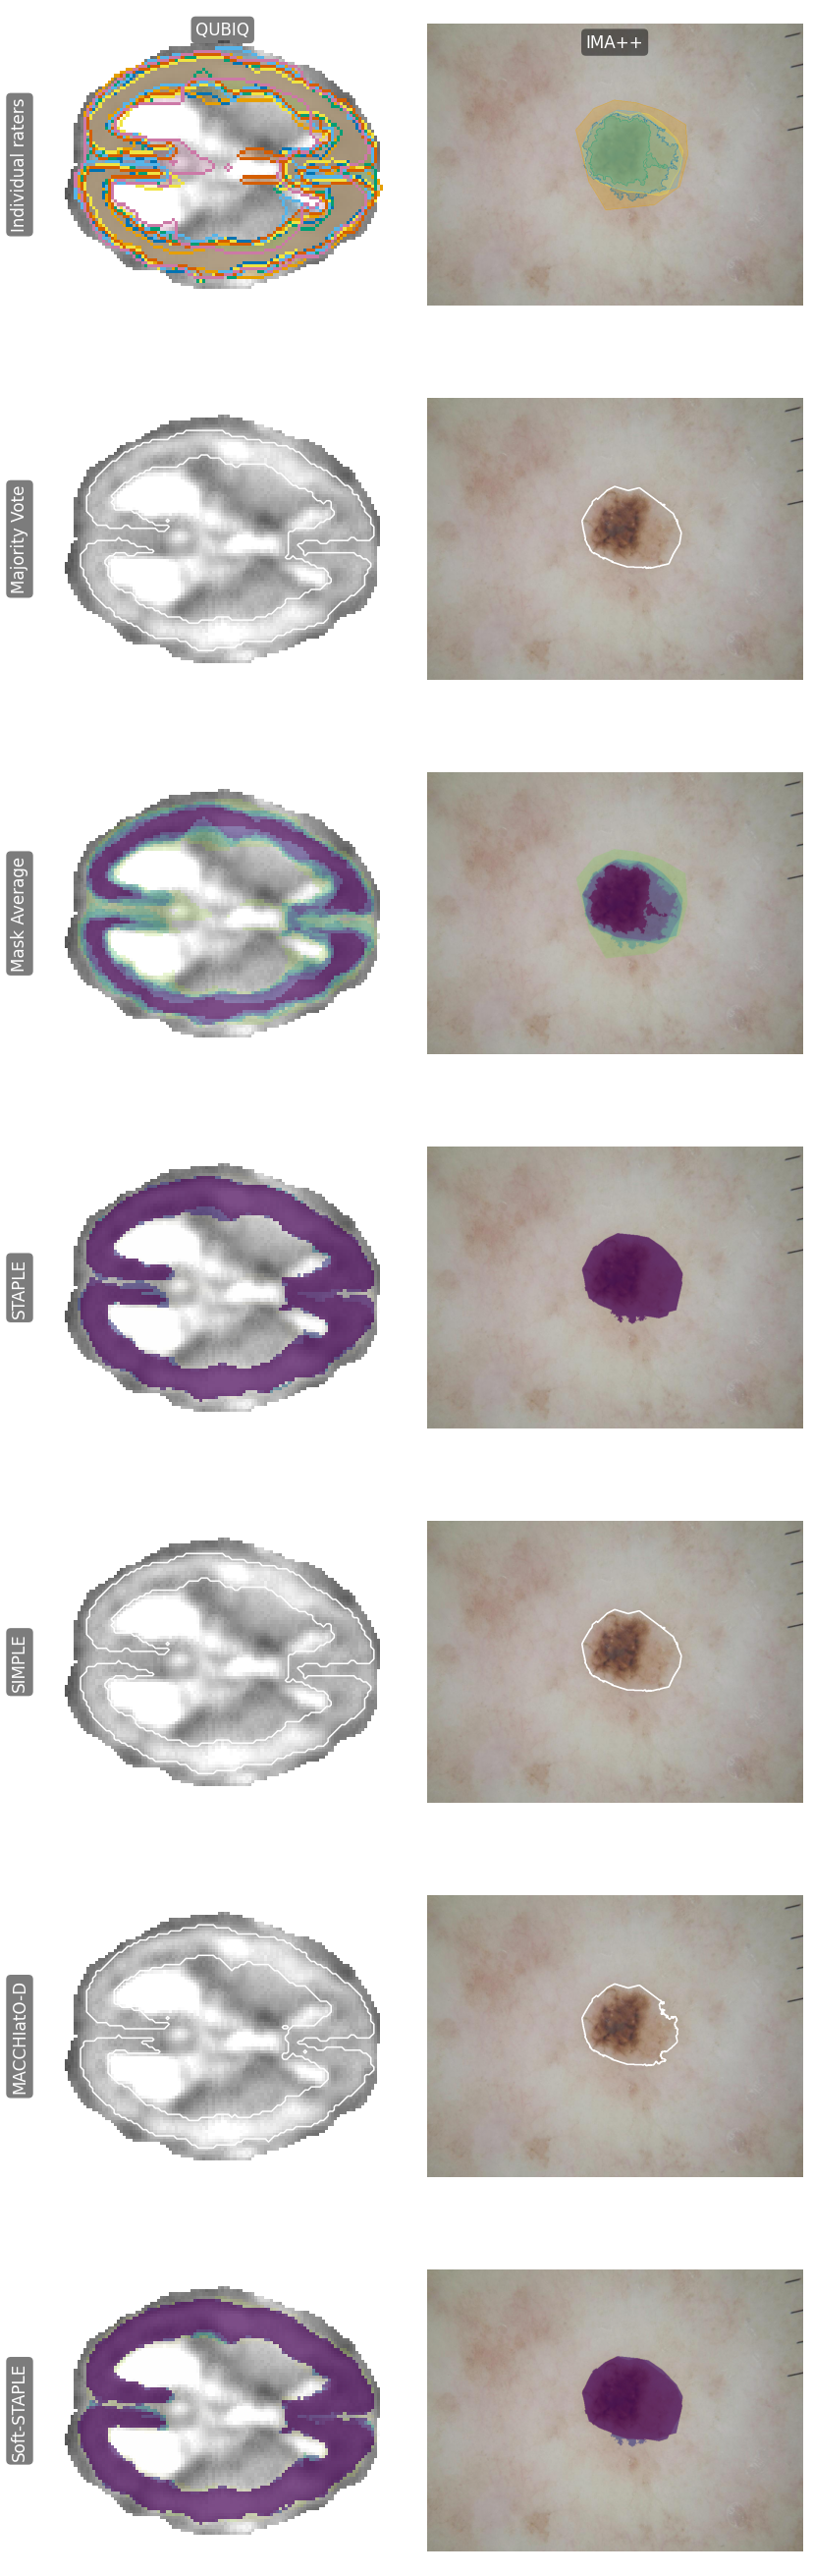

In [11]:
rows = [("Individual raters", None, "raters"),
        ("Majority Vote", ("mv", "ima_mv"), "hard"),
        ("Mask Average", ("ma", "ima_ma"), "soft"),
        ("STAPLE", ("staple", "ima_staple"), "soft"),
        ("SIMPLE", ("simple", "ima_simple"), "hard"),
        ("MACCHIatO-D", ("mac", "ima_mac"), "hard"),
        ("Soft-STAPLE", ("ss", "ima_ss"), "soft")]
panels = {
    "qubiq": {"image": q_img_c, "is_rgb": False, "masks": q_masks_c,
              "mv": qc(qubiq_mv), "ma": qc(qubiq_ma), "staple": qc(qubiq_staple),
              "simple": qc(qubiq_simple), "mac": qc(qubiq_mac_hard), "ss": qc(qubiq_ss_soft)},
    "ima": {"image": ima["image_rgb"], "is_rgb": True, "masks": ima_masks,
            "ima_mv": ima_mv, "ima_ma": ima_ma, "ima_staple": ima_staple,
            "ima_simple": ima_simple, "ima_mac": ima_mac_hard, "ima_ss": ima_ss_soft}}
fig, axes = plt.subplots(len(rows), 2, figsize=(7.6, 3.5 * len(rows)))
for r, (label, keys, kind) in enumerate(rows):
    for c, case in enumerate(["qubiq", "ima"]):
        ax = axes[r, c]; P = panels[case]
        if kind == "raters":
            show_raters(ax, P["image"], P["masks"], is_rgb=P["is_rgb"])
        elif kind == "soft":
            show_soft(ax, P["image"], P[keys[c]], is_rgb=P["is_rgb"])
        else:
            show_hard(ax, P["image"], P[keys[c]], is_rgb=P["is_rgb"])
        ax.axis("off")
        if c == 0:                                  # row label as a pill in the left margin
            ax.text(-0.04, 0.5, label, transform=ax.transAxes, rotation=90,
                    va="center", ha="center", fontsize=11, color="white", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.28", facecolor="#111111",
                              edgecolor="none", alpha=0.55))
    if r == 0:
        panel_title(axes[0, 0], "QUBIQ"); panel_title(axes[0, 1], "IMA++")
fig.tight_layout(); save_fig(fig, str(FIG_DIR / "all_methods")); plt.show()

## Save outputs

In [12]:
np.savez_compressed(
    PRECOMP_DIR / "consensus_results.npz",
    qubiq_image=qubiq["image"].astype(np.float32), qubiq_masks=qubiq_masks,
    qubiq_crop=np.array([q_crop[0].start or 0, q_crop[0].stop, q_crop[1].start or 0, q_crop[1].stop]),
    qubiq_vote_map=vote_map(qubiq_masks).astype(np.int16), qubiq_mv=qubiq_mv, qubiq_mask_average=qubiq_ma,
    qubiq_staple_soft=qubiq_staple, qubiq_staple_sens=q_sens, qubiq_staple_spec=q_spec,
    qubiq_staple_tight=staple_tight, qubiq_staple_tight_dims=staple_tight_dims,
    qubiq_staple_tight_bbox=np.array([y0, y1, x0, x1]), qubiq_simple_hard=qubiq_simple,
    qubiq_macchiato_hard=qubiq_mac_hard, qubiq_macchiato_soft=qubiq_mac_soft,
    qubiq_softstaple_soft=qubiq_ss_soft, qubiq_softstaple_binary_in=qubiq_ss_binary,
    qubiq_softstaple_wide=qubiq_ss_wide, qubiq_soft_labels=qubiq_soft_labels,
    ima_image=ima["image"].astype(np.float32), ima_image_rgb=ima["image_rgb"].astype(np.float32),
    ima_masks=ima_masks, ima_vote_map=vote_map(ima_masks).astype(np.int16),
    ima_mv=ima_mv, ima_mask_average=ima_ma,
    ima_staple_soft=ima_staple, ima_staple_sens=i_sens, ima_staple_spec=i_spec,
    ima_simple_hard=ima_simple, ima_macchiato_hard=ima_mac_hard, ima_macchiato_soft=ima_mac_soft,
    ima_softstaple_soft=ima_ss_soft)
print("saved npz + figures:", sorted(p.name for p in FIG_DIR.glob("*.png")))

saved npz + figures: ['all_methods.png', 'macchiato_comparison.png', 'mv_isolated_voxels.png', 'simple_robustness.png', 'softstaple_comparison.png', 'staple_bbox.png', 'staple_raters.png', 'vote_map_ima.png', 'vote_map_qubiq.png']
